## Fichier d'analyse des résulats

In [1]:
import pandas as pd
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib import font_manager
import os


In [29]:
# Paramètres pour les graphiques
font_dir = "assets"

for file in os.listdir(font_dir):
    if file.endswith(".ttf"):
        font_manager.fontManager.addfont(os.path.join(font_dir, file))

plt.rcParams["font.family"] = "Marianne"
plt.rcParams.update({
    "font.family": "Marianne",

    "axes.titlesize": 16,
    "axes.titleweight": "bold",

    "figure.titlesize": 18,
    "figure.titleweight": "bold",

    "axes.labelsize": 12,
    "axes.labelweight": "regular",

    "xtick.labelsize": 10,
    "ytick.labelsize": 10,

    "legend.fontsize": 10,
})

# Colors and styles for plotting
palette = {
    "Fioul":        "#80549f",
    "Charbon":      "#3d2a2a",
    "Bioénergies":  "#156956",
    "Gaz semi-base":"#f20809",
    "Gaz pointe":   "#f20809",
    "Gaz"       :   "#f20809",
    "Solaire":      "#d66b0d",
    "Hydro":        "#2672b0",
    "Onshore":       "#72cbb7",
    "Offshore":       "#4d8377",
    "H2_total":    "#e4a701",
    "STEP_charge": "#0c3949",
    "Fond":        "#ffffff",
    "STEP_decharge": "#0c3949",
    "Battery_charge": "#00bbff",
    "Battery_decharge": "#00bbff",
}

In [30]:
df = pd.read_csv('results.csv', sep=';')
df.drop(columns=['t'], inplace=True)

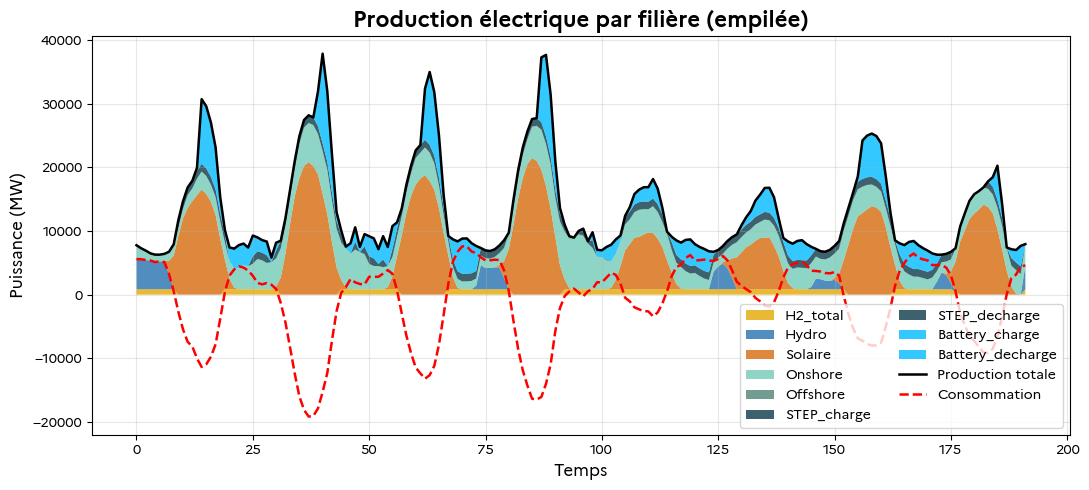

In [34]:
plt.figure(figsize=(11,5))

cols_to_stack = [c for c in df.columns if c not in ['Load', 'Net_load', 'RES']]

# Graphique empilé (Production)
plt.stackplot(
    df.index,
    [df[c] for c in cols_to_stack],
    colors=[palette[c] for c in cols_to_stack],
    labels=cols_to_stack,
    alpha=0.8
)

plt.plot(df.index, df[cols_to_stack].sum(axis=1), color="black", linewidth=1.8, label="Production totale")
plt.plot(df.index, df['Net_load'], color="red", linestyle='--', linewidth=1.8, label="Consommation")

plt.title("Production électrique par filière (empilée)")
plt.xlabel("Temps")
plt.ylabel("Puissance (MW)")
plt.legend(ncol=2)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

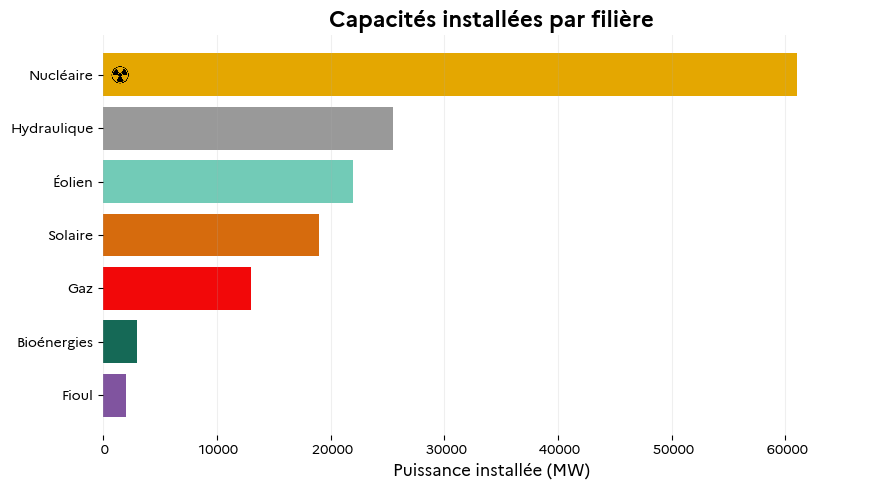

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
import matplotlib.ticker as mtick
import os

def add_icon(ax, x, y, icon_path, zoom=0.08):
    """Ajoute une icône (image) aux coordonnées data (x, y)."""
    if not os.path.exists(icon_path):
        return
    img = plt.imread(icon_path)
    ab = AnnotationBbox(OffsetImage(img, zoom=zoom), (x, y),
                        frameon=False, box_alignment=(0, 0.5))
    ax.add_artist(ab)

# Exemple de données (MW)
data = {
    "Nucléaire": 61000,
    "Hydraulique": 25500,
    "Éolien": 22000,
    "Solaire": 19000,
    "Gaz": 13000,
    "Bioénergies": 3000,
    "Fioul": 2000,
}

# Icônes associées
icons = {
    "Nucléaire": "assets/nuc.png",
    "Hydraulique": "assets/icons/hydraulique.png",
    "Éolien": "assets/icons/eolien.png",
    "Solaire": "assets/icons/solaire.png",
    "Gaz": "assets/icons/gaz.png",
    "Bioénergies": "assets/icons/bioenergies.png",
    "Fioul": "assets/icons/fioul.png",
}


labels = list(data.keys())
values = list(data.values())
colors = [palette.get(k, "#999999") for k in labels]

fig, ax = plt.subplots(figsize=(9, 5))
fig.patch.set_facecolor(palette["Fond"])
ax.set_facecolor(palette["Fond"])

# Barres horizontales triées (plus visuel)
labels, values, colors = zip(*sorted(zip(labels, values, colors), key=lambda t: t[1]))
bars = ax.barh(labels, values, color=colors)

# Axes + format
ax.set_title("Capacités installées par filière", fontweight="bold")
ax.set_xlabel("Puissance installée (MW)")
ax.xaxis.set_major_formatter(mtick.StrMethodFormatter("{x:,.0f}".replace(",", " ")))

# Place les icônes juste avant l’origine (légèrement à gauche)
xmin, xmax = ax.get_xlim()
icon_x = xmin + (xmax - xmin) * 0.01  # un poil à droite du bord
for y, label in enumerate(labels):
    add_icon(ax, icon_x, y, icons.get(label, ""), zoom=0.07)

# Un peu d’air à gauche pour voir les icônes
ax.margins(x=0.12)

# Grille légère (optionnel)
ax.grid(axis="x", alpha=0.2)
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout()
plt.show()